# Мета-лейблинг v2: ~50 фичей + квартальный walk-forward

Отличия от v1:
1. **Фичей ~50 вместо 18** — портфель (моментумы, вола, скошенность, автокорреляция,
   просадка), каждая альфа отдельно, согласие альф, режим рынка (BTC, breadth,
   кросс-секционная дисперсия, прокси средней корреляции, ликвидность, funding),
   календарь (выходные — в крипте это реальный режим).
2. **Честная оценка после потраченного TEST-бюджета:** v1 уже подглянула в TEST,
   поэтому здесь модель переобучается **walk-forward** — расширяющееся окно, рефит
   каждые 63 бара, предсказываются только будущие бары. Всё после стартового окна —
   настоящий out-of-sample. Строку TEST всё равно показываем отдельно, но помним:
   это уже второй заход на этот отрезок — к нему скидка на multiple testing.
3. Бейзлайн **«константный размер, равный среднему размеру меты»** — урок v1:
   именно он, а не always-on, разоблачает «выигрыш за счёт маленькой позиции».
4. Разбор фичей: |коэффициенты| логрега и permutation importance бустинга.

In [1]:
import os, sys, json, warnings, difflib, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore'); np.seterr(all='ignore')
PROJ = os.getcwd()
S = json.load(open(os.path.join(PROJ, 'alphanode', 'gui_settings.json')))
TF = S.get('timeframe', '1d')
os.environ['ALPHANODE_TF'] = TF
sys.path[:0] = [os.path.join(PROJ, 'evolution'), PROJ]
from config import load_config
from evaluator import build_panel, make_market, eval_alpha_panel, basket_returns
from fastsim import fast_sim
from genome import parse

cfg = load_config()
ANN, FREQ = float(cfg.get('ann', 365.0)), cfg.get('freq', 'D')
VOL, EXEC = float(S['target_vol']), float(S['exec_cost'])
DATA = os.path.join(PROJ, 'data.pickle' if TF == '1d' else f'data_{TF}.pickle')
LIB = os.path.join(PROJ, 'alphanode', 'state',
                   'library.jsonl' if TF == '1d' else f'library_{TF}.jsonl')
TR, VA, TE, EN = (pd.Timestamp(S[k], tz='UTC') for k in
                  ('train_start', 'val_start', 'test_start', 'test_end'))
N_ALPHAS, SIZE_COST, EMBARGO, HGB_SEEDS = 5, 0.0010, 5, 5
WF_START, WF_STEP = 500, 63                            # first fit after 500 bars, refit quarterly
print(f'tf={TF} ann={ANN:g} vol={VOL} exec={EXEC} · WF: start {WF_START}, step {WF_STEP}')

tf=1d ann=365 vol=0.36 exec=0.0005 · WF: start 500, step 63


In [2]:
rows = [json.loads(l) for l in open(LIB, encoding='utf-8')]
rows = [r for r in rows if r.get('formula') and isinstance(r.get('base'), (int, float))]
rows.sort(key=lambda c: c['base'], reverse=True)
picked = []
for c in rows:
    if all(difflib.SequenceMatcher(None, c['formula'], p['formula']).ratio() < 0.80
           for p in picked):
        picked.append(c)
    if len(picked) == N_ALPHAS:
        break

tk, raw, panel = build_panel(DATA, TR.tz_localize(None).to_pydatetime(),
                             EN.tz_localize(None).to_pydatetime(), None, freq=FREQ)
market = make_market(panel, tk, raw, vol_window=cfg.get('vol_window', 30))
R = {}
for c in picked:
    ap = eval_alpha_panel(parse(c['formula']), panel)
    R[c['formula'][:40]] = fast_sim(ap[tk].to_numpy(dtype=np.float64), market, VOL, EXEC,
                                    ann=ANN, ewma_lambda=cfg.get('ewma_lambda', 0.06))
R = pd.DataFrame(R).fillna(0.0)
p = R.mean(axis=1)
idx = p.index
m_train = (idx >= TR) & (idx < VA)
m_val   = (idx >= VA) & (idx < TE)
m_test  = (idx >= TE) & (idx < EN)
m_sel   = m_train | m_val
print(f'{len(p)} bars · primary = EW portfolio of {N_ALPHAS} alphas')

2496 bars · primary = EW portfolio of 5 alphas


## 1. Фичи — всё считается строго из прошлого

In [3]:
F = pd.DataFrame(index=idx)
# --- the portfolio itself ---
for w in (5, 10, 21, 42, 63, 126):
    F[f'mom{w}'] = p.rolling(w).sum()
for w in (5, 21, 63):
    F[f'vol{w}'] = p.rolling(w).std() * np.sqrt(ANN)
F['volvol'] = F['vol21'].rolling(21).std()
F['skew21'], F['skew63'] = p.rolling(21).skew(), p.rolling(63).skew()
F['kurt21'] = p.rolling(21).kurt()
F['dvol21'] = p.clip(upper=0).rolling(21).std() * np.sqrt(ANN)   # downside vol
eq = (1 + p).cumprod()
dd = eq / eq.cummax() - 1
F['dd'] = dd
F['dd_days'] = (dd < 0).astype(int).groupby((dd >= 0).cumsum()).cumsum()
F['since_high'] = (eq < eq.cummax()).astype(int).groupby((eq >= eq.cummax()).cumsum()).cumsum()
F['sh21'] = p.rolling(21).mean() / (p.rolling(21).std() + 1e-12)
F['sh63'] = p.rolling(63).mean() / (p.rolling(63).std() + 1e-12)
F['ac1'] = p.rolling(21).corr(p.shift(1))
F['win21'] = (p > 0).rolling(21).mean()
# --- each alpha separately + their agreement ---
for i, col in enumerate(R.columns):
    r = R[col]
    F[f'a{i}_sh21'] = r.rolling(21).mean() / (r.rolling(21).std() + 1e-12)
    F[f'a{i}_sh63'] = r.rolling(63).mean() / (r.rolling(63).std() + 1e-12)
sh21s = F[[f'a{i}_sh21' for i in range(N_ALPHAS)]]
F['a_spread'] = sh21s.max(axis=1) - sh21s.min(axis=1)  # best vs worst alpha now
F['disp'] = R.std(axis=1)
pc = R.rolling(63).corr()
mask_od = ~np.eye(N_ALPHAS, dtype=bool)
F['acorr63'] = pc.groupby(level=0).apply(lambda m: m.values[mask_od].mean())
# --- market regime ---
rets = panel['ret']
btc_col = next((c for c in rets.columns if 'BTC' in c), None)
btc = rets[btc_col].reindex(idx).fillna(0.0) if btc_col else basket_returns(panel).reindex(idx).fillna(0.0)
for w in (21, 63, 126):
    F[f'btc_mom{w}'] = btc.rolling(w).sum()
F['btc_vol21'] = btc.rolling(21).std() * np.sqrt(ANN)
F['btc_vol63'] = btc.rolling(63).std() * np.sqrt(ANN)
beq = (1 + btc).cumprod()
F['btc_dd'] = beq / beq.cummax() - 1
bk = basket_returns(panel).reindex(idx).fillna(0.0)
F['mkt_mom21'] = bk.rolling(21).sum()
F['breadth21'] = (rets.rolling(21).sum() > 0).mean(axis=1).reindex(idx)
F['breadth63'] = (rets.rolling(63).sum() > 0).mean(axis=1).reindex(idx)
F['xdisp'] = rets.std(axis=1).rolling(21).mean().reindex(idx)    # cross-sectional dispersion
# avg-correlation proxy: basket var vs mean asset var (high -> assets move as one)
F['corr_proxy'] = (bk.rolling(21).var() /
                   (rets.rolling(21).var().mean(axis=1).reindex(idx) + 1e-12))
if 'dvol' in panel:
    mdv = panel['dvol'].sum(axis=1).reindex(idx)
    F['liq_mom21'] = np.log(mdv + 1).diff().rolling(21).sum()    # liquidity regime
if 'funding' in panel:
    fu = panel['funding']
    F['fund7'] = fu.mean(axis=1).rolling(7).mean().reindex(idx)
    F['fund_disp'] = fu.std(axis=1).rolling(7).mean().reindex(idx)
    F['fund_mom21'] = fu.mean(axis=1).rolling(21).sum().reindex(idx)
# --- calendar (weekends are a real crypto regime) ---
F['is_weekend'] = (idx.dayofweek >= 5).astype(int)
F['dow_sin'] = np.sin(2 * np.pi * idx.dayofweek / 7)
F['dow_cos'] = np.cos(2 * np.pi * idx.dayofweek / 7)

y = (p.shift(-1) > 0).astype(int)
w_smp = p.shift(-1).abs()
valid = (~F.isna().any(axis=1)) & w_smp.notna()
X = F.values
FEAT = list(F.columns)
print(f'{len(FEAT)} features · usable bars {valid.sum()} of {len(p)}')

52 features · usable bars 2244 of 2496


## 2. Purged CV на TRAIN+VAL: есть ли сигнал, и какие фичи его несут

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

def make_logreg():
    return LogisticRegression(C=0.25, max_iter=3000)

def make_hgb(seed):
    return HistGradientBoostingClassifier(max_depth=3, max_leaf_nodes=7,
                                          learning_rate=0.05, max_iter=200,
                                          l2_regularization=1.0, random_state=seed)

def fit_predict(model, tr_ix, pr_ix, scale):
    sc = StandardScaler().fit(X[tr_ix]) if scale else None
    model.fit(sc.transform(X[tr_ix]) if scale else X[tr_ix], y.values[tr_ix],
              sample_weight=w_smp.values[tr_ix])
    return model, model.predict_proba(sc.transform(X[pr_ix]) if scale else X[pr_ix])[:, 1]

sel_ix = np.where(m_sel & valid.values)[0]
edges = np.linspace(0, len(sel_ix), 6).astype(int)
cv_rows, last_fold = [], None
for k, (a, b) in enumerate(zip(edges[1:-1], edges[2:])):
    tr_ix, va_ix = sel_ix[:max(0, a - EMBARGO)], sel_ix[a:b]
    _, pl = fit_predict(make_logreg(), tr_ix, va_ix, scale=True)
    ph = np.mean([fit_predict(make_hgb(s), tr_ix, va_ix, scale=False)[1]
                  for s in range(HGB_SEEDS)], axis=0)
    aucs = [roc_auc_score(y.values[va_ix], q, sample_weight=w_smp.values[va_ix])
            for q in (pl, ph, (pl + ph) / 2)]
    cv_rows.append(aucs)
    last_fold = (tr_ix, va_ix)
    print(f'fold {k + 1}: train {len(tr_ix):4d} val {len(va_ix):4d} · '
          f'logreg {aucs[0]:.3f} · hgb {aucs[1]:.3f} · ens {aucs[2]:.3f}')
cv = np.array(cv_rows)
print(f'mean CV AUC: logreg {cv[:, 0].mean():.3f} · hgb {cv[:, 1].mean():.3f} · '
      f'ensemble {cv[:, 2].mean():.3f}')

# which features carry whatever signal there is (on the LAST fold)
tr_ix, va_ix = last_fold
lm, _ = fit_predict(make_logreg(), tr_ix, va_ix, scale=True)
hm, _ = fit_predict(make_hgb(0), tr_ix, va_ix, scale=False)
pi = permutation_importance(hm, X[va_ix], y.values[va_ix], n_repeats=5,
                            random_state=0, scoring='roc_auc')
imp = pd.DataFrame({'feature': FEAT,
                    'logreg |coef|': np.abs(lm.coef_[0]).round(3),
                    'hgb perm. AUC drop': pi.importances_mean.round(4)})
imp.sort_values('hgb perm. AUC drop', ascending=False).head(12)

fold 1: train  187 val  193 · logreg 0.564 · hgb 0.519 · ens 0.579


fold 2: train  380 val  192 · logreg 0.574 · hgb 0.590 · ens 0.604


fold 3: train  572 val  193 · logreg 0.519 · hgb 0.596 · ens 0.582


fold 4: train  765 val  193 · logreg 0.596 · hgb 0.531 · ens 0.544
mean CV AUC: logreg 0.563 · hgb 0.559 · ensemble 0.577


,feature,logreg |coef|,hgb perm. AUC drop
23,a1_sh21,0.005,0.0128
21,a0_sh21,0.047,0.0079
44,corr_proxy,0.028,0.0046
31,a_spread,0.021,0.0044
32,disp,0.003,0.0040
41,breadth21,0.022,0.0038
15,dd_days,0.002,0.0037
8,vol63,0.017,0.0033
18,sh63,0.023,0.0032
0,mom5,0.009,0.0019


## 3. Walk-forward: рефит каждые 63 бара, предсказываются только будущие бары

In [5]:
val_ix = np.where(valid.values)[0]
P_wf = np.full(len(p), np.nan)
chunks = []
for start in range(WF_START, len(val_ix), WF_STEP):
    tr_ix = val_ix[:max(0, start - EMBARGO)]
    pr_ix = val_ix[start:start + WF_STEP]
    if len(pr_ix) == 0:
        break
    _, pl = fit_predict(make_logreg(), tr_ix, pr_ix, scale=True)
    ph = np.mean([fit_predict(make_hgb(s), tr_ix, pr_ix, scale=False)[1]
                  for s in range(HGB_SEEDS)], axis=0)
    P_wf[pr_ix] = (pl + ph) / 2
    if len(np.unique(y.values[pr_ix])) > 1:
        chunks.append({'end': idx[pr_ix[-1]],
                       'auc': roc_auc_score(y.values[pr_ix], P_wf[pr_ix],
                                            sample_weight=w_smp.values[pr_ix])})
P_wf = pd.Series(P_wf, index=idx)
oos = P_wf.notna()
print(f'{len(chunks)} refits · WF-OOS bars: {oos.sum()} '
      f'({idx[oos.values.argmax()].date()} .. {idx[-1].date()})')
wf_ix = np.where(oos.values)[0]
print(f'WF-OOS AUC overall: '
      f'{roc_auc_score(y.values[wf_ix], P_wf.values[wf_ix], sample_weight=w_smp.values[wf_ix]):.3f}')
ch = pd.DataFrame(chunks)
print(f'per-refit AUC: median {ch["auc"].median():.3f} · '
      f'>{0.5} in {(ch["auc"] > 0.5).mean():.0%} of chunks')

28 refits · WF-OOS bars: 1744 (2021-09-25 .. 2026-07-05)
WF-OOS AUC overall: 0.513
per-refit AUC: median 0.539 · >0.5 in 68% of chunks


In [6]:
def size_from_prob(P):
    z = (P - 0.5) / np.sqrt(np.clip(P * (1 - P), 1e-6, None))
    m = 2 * pd.Series(z, index=idx).apply(
        lambda v: 0.5 * (1 + math.erf(v / math.sqrt(2))) if np.isfinite(v) else np.nan) - 1
    return m.clip(lower=0.0, upper=1.0).ewm(span=3).mean()

def throttled(s):
    s_lag = s.shift(1)
    r = s_lag * p - SIZE_COST * s_lag.diff().abs()
    return r

s_wf = size_from_prob(P_wf)
meta_wf = throttled(s_wf)
mean_s = s_wf[oos].mean()
const = throttled(pd.Series(mean_s, index=idx).where(oos))       # the v1 lesson, built in
vol_ref = p[m_train].rolling(21).std().median() * np.sqrt(ANN)
s_vol = (vol_ref / (p.rolling(21).std() * np.sqrt(ANN))).clip(upper=1.0)
ivol = throttled(s_vol.where(oos))

def metrics(r, mask):
    r = r.values[mask & np.isfinite(r.values)]
    if (r != 0).sum() < 5 or r.std() < 1e-12:
        return dict(sharpe=np.nan, cagr=np.nan, dd=np.nan)
    eq = np.cumprod(1 + r); yrs = len(r) / ANN
    return dict(sharpe=r.mean() * ANN / (r.std() * np.sqrt(ANN)),
                cagr=eq[-1] ** (1 / yrs) - 1 if eq[-1] > 0 else np.nan,
                dd=(eq / np.maximum.accumulate(eq) - 1).min())

m_oos = oos.values
segs = [('WF-OOS (весь)', m_oos), ('WF-OOS ∩ VAL', m_oos & m_val),
        ('WF-OOS ∩ TEST', m_oos & m_test)]
out = []
for name, r in [('meta WF ensemble', meta_wf), (f'constant size {mean_s:.2f}', const),
                ('inverse-vol', ivol), ('primary (always on)', p)]:
    row = {'strategy': name}
    for seg_name, mask in segs:
        m = metrics(r, mask)
        row[f'{seg_name} sharpe'] = round(m['sharpe'], 2)
        row[f'{seg_name} dd'] = f"{m['dd']:.0%}" if np.isfinite(m['dd']) else '—'
    out.append(row)
print(f'mean meta size on WF-OOS: {mean_s:.2f}')
pd.DataFrame(out)

mean meta size on WF-OOS: 0.20


,strategy,WF-OOS (весь) sharpe,WF-OOS (весь) dd,WF-OOS ∩ VAL sharpe,WF-OOS ∩ VAL dd,WF-OOS ∩ TEST sharpe,WF-OOS ∩ TEST dd
0,meta WF ensemble,1.84,-10%,3.68,-2%,1.16,-10%
1,constant size 0.20,2.19,-7%,3.96,-2%,1.65,-7%
2,inverse-vol,2.12,-23%,4.01,-6%,1.55,-23%
3,primary (always on),2.17,-32%,3.96,-8%,1.65,-32%


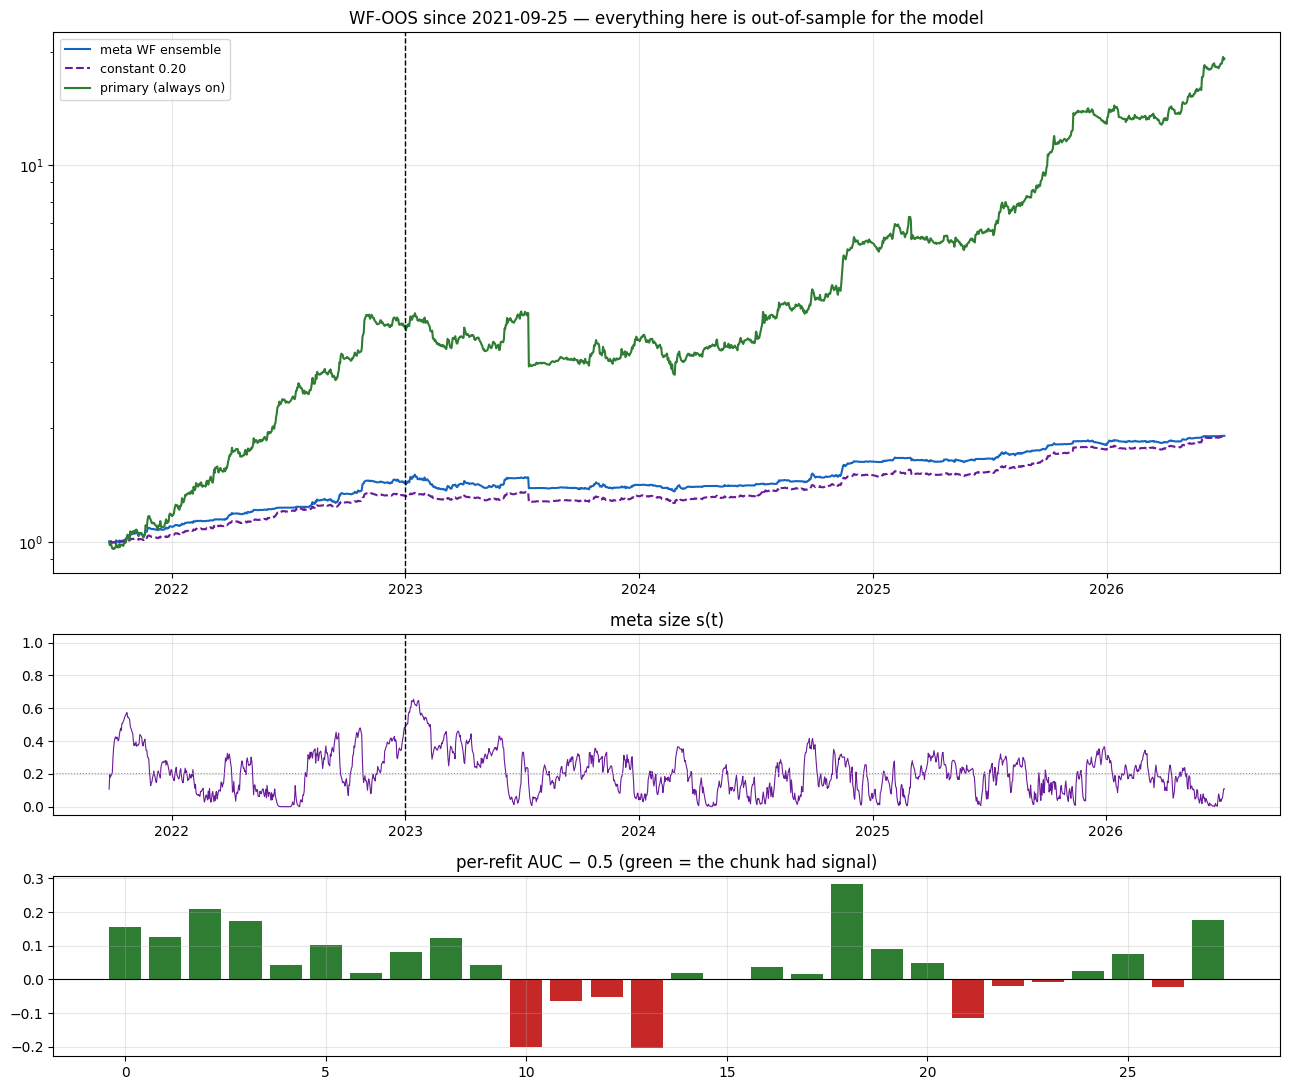

In [7]:
fig, (ax, ax2, ax3) = plt.subplots(3, 1, figsize=(13, 11),
                                   gridspec_kw={'height_ratios': [3, 1, 1]})
start = idx[oos.values.argmax()]
for r, lbl, col, ls in [(meta_wf, 'meta WF ensemble', '#1565c0', '-'),
                        (const, f'constant {mean_s:.2f}', '#6a1b9a', '--'),
                        (p.where(oos), 'primary (always on)', '#2e7d32', '-')]:
    rr = r[oos].fillna(0.0)
    ax.plot(rr.index, (1 + rr).cumprod(), lw=1.5, color=col, ls=ls, label=lbl)
ax.set_yscale('log'); ax.grid(alpha=0.3); ax.legend(loc='upper left', fontsize=9)
ax.axvline(TE, color='k', ls='--', lw=1)
ax.set_title(f'WF-OOS since {start.date()} — everything here is out-of-sample for the model')
ax2.plot(idx, s_wf, lw=0.8, color='#6a1b9a')
ax2.axhline(mean_s, color='#999', lw=0.8, ls=':')
ax2.set_ylim(-0.05, 1.05); ax2.grid(alpha=0.3); ax2.axvline(TE, color='k', ls='--', lw=1)
ax2.set_title('meta size s(t)')
ch = pd.DataFrame(chunks)
ax3.bar(range(len(ch)), ch['auc'] - 0.5, color=['#2e7d32' if a > 0.5 else '#c62828'
                                                for a in ch['auc']])
ax3.axhline(0, color='k', lw=0.8)
ax3.set_title('per-refit AUC − 0.5 (green = the chunk had signal)')
ax3.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Как читать

- **Главная строка — «WF-OOS (весь)»**: ~5 лет честного out-of-sample вместо одного
  1000-барного TEST. Диаграмма per-refit AUC показывает, был ли сигнал стабильным
  или это пара удачных кварталов.
- **Сравнивай мету с константой её же среднего размера** — урок v1. Бьёт константу
  по dd при сравнимом Sharpe → модель действительно знает «когда». Не бьёт →
  вся ценность в масштабе позиции, ML не нужен.
- Колонка «WF-OOS ∩ TEST» — это уже **второй** взгляд на TEST в этой серии
  экспериментов; относись к ней с дисконтом.
- Больше фичей ≠ лучше: если CV AUC вырос, а WF-OOS остался ~0.5 — новые фичи
  дали моделям больше места переобучиться, ровно это мы и проверяли.